Model SVM załadowany pomyślnie!


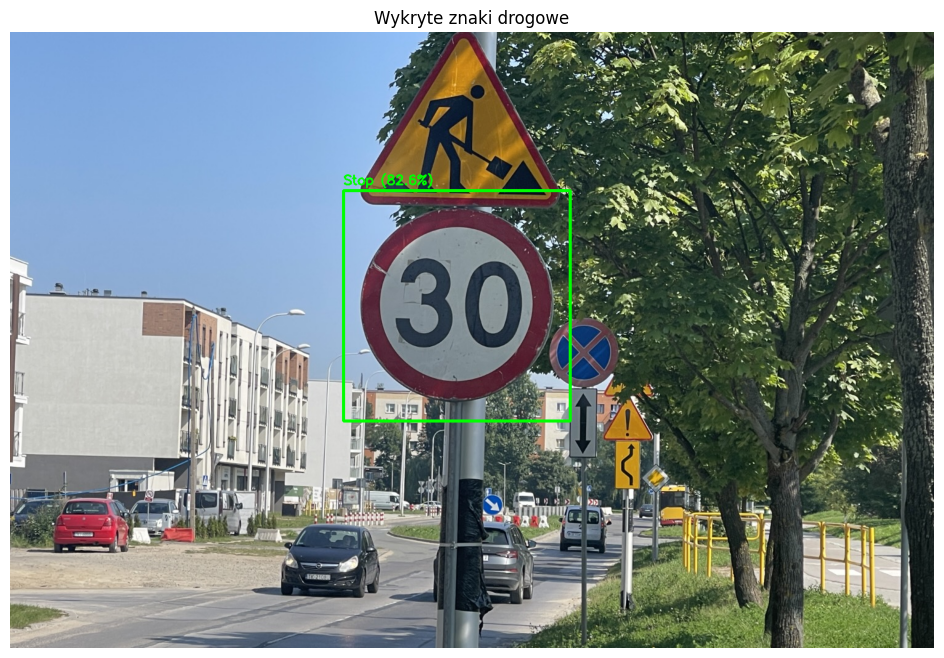

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
import joblib
import os

# --- 1. WCZYTANIE MODELU ---
model_path = '../models/svm_model.pkl'
svm_model = joblib.load(model_path)
print("Model SVM załadowany pomyślnie!")

IMG_SIZE = (64, 64)

def extract_hog_features(img_roi):
    """Funkcja pomocnicza: przygotowuje wycięty znak dla SVM"""
    resized = cv2.resize(img_roi, IMG_SIZE)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    features = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
    return features.reshape(1, -1) # SVM wymaga tablicy 2D

# --- 2. GŁÓWNA FUNKCJA DETEKCJI ---
def detect_and_classify_signs(image_path):
    # Wczytanie obrazu
    img = cv2.imread(image_path)
    if img is None:
        print(f"Błąd wczytania obrazu: {image_path}")
        return
    
    img_copy = img.copy()
    
    # Konwersja do HSV dla łatwiejszego wyłapywania kolorów
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Definiowanie zakresów kolorów w OpenCV (HSV)
    # Czerwony jest złośliwy, bo w OpenCV jest na obu końcach skali (0-10 i 160-180)
    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([160, 70, 50])
    upper_red2 = np.array([180, 255, 255])
    
    # Żółty (dla znaku Droga z pierwszeństwem)
    lower_yellow = np.array([15, 70, 50])
    upper_yellow = np.array([35, 255, 255])
    
    # Tworzenie masek dla kolorów
    mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)
    
    # Połączenie masek (Czerwony + Żółty)
    mask_combined = mask_red1 + mask_red2 + mask_yellow
    
    # Oczyszczanie maski (usuwanie szumów)
    kernel = np.ones((3, 3), np.uint8)
    mask_clean = cv2.morphologyEx(mask_combined, cv2.MORPH_OPEN, kernel)
    mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel)
    
    # Znajdowanie konturów na oczyszczonej masce
    contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        # Pudełko otaczające kontur (Bounding Box)
        x, y, w, h = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)
        aspect_ratio = w / float(h)
        
        # Filtrujemy szumy: znak musi być odpowiednio duży i w miarę "kwadratowy" (proporcje boków ok 1.0)
        if area > 400 and 0.7 < aspect_ratio < 1.3:
            
            # Dodajemy mały margines do wycięcia, żeby ująć cały znak
            margin = int(0.1 * w)
            x1 = max(0, x - margin)
            y1 = max(0, y - margin)
            x2 = min(img.shape[1], x + w + margin)
            y2 = min(img.shape[0], y + h + margin)
            
            # Wycinamy potencjalny znak ze zdjęcia
            roi = img[y1:y2, x1:x2]
            
            # Wyciągamy cechy HOG i klasyfikujemy w SVM
            features = extract_hog_features(roi)
            
            # predict_proba pozwala sprawdzić pewność modelu (jeśli masz kernel='linear', musi być włączone probability=True przy treningu)
            prediction = svm_model.predict(features)[0]
            probabilities = svm_model.predict_proba(features)[0]
            max_prob = np.max(probabilities)
            
            # Rysujemy ramkę, tylko jeśli model jest na 70% pewny, że to nasz znak
            if max_prob > 0.70:
                cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 3) # Zielona ramka
                
                # Dodajemy etykietę (tekst)
                label = f"{prediction} ({max_prob*100:.1f}%)"
                cv2.putText(img_copy, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                
    # Wyświetlanie wyniku w Matplotlib
    plt.figure(figsize=(12, 8))
    img_rgb = cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title("Wykryte znaki drogowe")
    plt.axis('off')
    plt.show()

# --- 3. TESTOWANIE NA TWOIM ZDJĘCIU ---
# Podmień poniższą nazwę na nazwę zdjęcia, które wrzuciłeś do data/test_images/
test_image = '../data/test_images/1.jpg'

if os.path.exists(test_image):
    detect_and_classify_signs(test_image)
else:
    print(f"Wrzuć jakieś zdjęcie do {test_image} i podmień nazwę w kodzie!")